# CISI Corpus Text Preprocessing Pipeline

This notebook implements a complete text preprocessing and normalization pipeline using the **CISI corpus** as the input dataset.

### Pipeline Steps Included:
1. **Dataset Loading & Parsing**: Downloading and extracting the CISI textual fields.
2. **Case Normalization**: Converting text to lowercase.
3. **Diacritics Removal**: Stripping accents and normalizing unicode characters.
4. **Jargon, Abbreviation & URL Normalization**: Cleaning non-standard textual noise and expanding short forms.
5. **Tokenization**: Segmenting sentences into individual token units.
6. **Noise & Punctuation Removal**: Eliminating numbers, punctuation signs, and non-informative symbols.
7. **Stopword Removal**: Filtering out high-frequency words with low semantic value.
8. **Stemming**: Reducing words to their crude base/root form.
9. **Lemmatization**: Resolving tokens to their dictionary form (lemma) using linguistic context.

---
## 0. Environment Setup & Dependencies
We start by installing and importing required libraries like `nltk` for NLP tasks and `unicodedata` for text normalization.

In [35]:
import importlib
import subprocess
import sys

librerias_proyecto = {"numpy": "numpy",
             "pandas": "pandas",
             "matplotlib":"matplotlib",
             "seaborn":"seaborn",
             "openpyxl": "openpyxl",
             "nltk": "nltk",
             "requests": "requests",
             "contractions": "contractions",
             "gensim": "gensim",
             }
             
print("====== INICIANDO VERIFICACIÓN DE ENTORNO ======\n")

# 2. Recorrer y validar cada librería de la lista
for nombre_importar, nombre_pip in librerias_proyecto.items():
    instalada = False
    
    while not instalada:
        try:
            # Intenta cargar la librería dinámicamente
            modulo = importlib.import_module(nombre_importar)
            instalada = True
            
            # Obtener la versión de forma segura
            version = getattr(modulo, "__version__", "Versión no expuesta")
            print(f"[{nombre_importar}] Lista para usar. Versión: {version}")
            
        except ImportError:
            print(f"[{nombre_importar}] No encontrada. Instalando vía pip: '{nombre_pip}'...")
            try:
                # Instala usando el entorno de Python que está ejecutando el script
                subprocess.check_call([sys.executable, "-m", "pip", "install", nombre_pip])
                print(f"[{nombre_importar}] Instalación enviada. Validando acceso...")
            except subprocess.CalledProcessError:
                print(f"[ERROR CRÍTICO] Falló la instalación de '{nombre_pip}'.")
                print("Revisa tu conexión a internet o los permisos de administrador.\n")
                break  # Rompe el ciclo while de esta librería para pasar a la siguiente

print("\n====== PROCESO DE CONFIGURACIÓN FINALIZADO ======")

====== INICIANDO VERIFICACIÓN DE ENTORNO ======

[numpy] Lista para usar. Versión: 2.1.3
[pandas] Lista para usar. Versión: 2.2.3
[matplotlib] Lista para usar. Versión: 3.10.0
[seaborn] Lista para usar. Versión: 0.13.2
[openpyxl] Lista para usar. Versión: 3.1.5
[nltk] Lista para usar. Versión: 3.9.1
[requests] Lista para usar. Versión: 2.32.4
[contractions] Lista para usar. Versión: Versión no expuesta
[gensim] Lista para usar. Versión: 4.4.0

====== PROCESO DE CONFIGURACIÓN FINALIZADO ======


## 1. Setup

Install/import the libraries used in the pipeline:

- `nltk` — tokenization, stopwords, stemming, lemmatization, POS tagging
- `contractions` — expands informal contractions ("don't" → "do not") as part of slang/jargon normalization
- `unicodedata` (standard library) — strips diacritics/accents
- `re` (standard library) — regex-based noise removal
- `pandas` — tabular handling of the corpus and results
- `matplotlib` — small before/after visual comparison

In [36]:
import re
import os
import string
import unicodedata
import collections
from pathlib import Path

import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

import contractions

# Download essential NLTK resources
NLTK_PACKAGES = [
    "punkt",
    "punkt_tab",
    "stopwords",
    "wordnet",
    "omw-1.4",
    #"averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]
for pkg in NLTK_PACKAGES:
    try:
        nltk.download(pkg, quiet=True)
    except Exception as e:
        print(f"Could not download '{pkg}': {e}")

print("Setup complete.")

Setup complete.



## 3. Building the pipeline — one technique at a time

Each preprocessing technique is implemented as a small, independent, well-documented function
first, then combined into a single configurable class in Section 4. Building them independently
makes it easy to inspect what each step does to the text.

We'll use a short synthetic sentence that packs in several of the phenomena the pipeline must
handle (URL, email, accents, numbers, punctuation, an informal contraction, and a couple of
abbreviations), in addition to the real CISI documents.


In [37]:

demo_text = (
    "Café résumé: the 18th Ed. of the Naïve Bayes Classification System — see "
    "http://example.com/paper, or e-mail info@example.com. It's approx. 1876 vs. 1971; "
    "don't u think the govt. dept. should update the catalog #libraries!!"
)
print(demo_text)


Café résumé: the 18th Ed. of the Naïve Bayes Classification System — see http://example.com/paper, or e-mail info@example.com. It's approx. 1876 vs. 1971; don't u think the govt. dept. should update the catalog #libraries!!



### 3.1 Case normalization

Converting all text to lowercase so that, e.g., `"Library"`, `"library"`, and `"LIBRARY"` are
treated as the same token. This is done early, since several later steps (stopword lists,
abbreviation dictionary lookups) are easiest to match in a single case.


In [38]:

def normalize_case(text: str) -> str:
    '''Lowercase the text.'''
    return text.lower()


print(normalize_case(demo_text))


café résumé: the 18th ed. of the naïve bayes classification system — see http://example.com/paper, or e-mail info@example.com. it's approx. 1876 vs. 1971; don't u think the govt. dept. should update the catalog #libraries!!



### 3.2 Diacritics (accent) removal

Accented characters (e.g. `é`, `ï`, `ñ`) are normalized to their closest plain-ASCII form using
Unicode's NFKD decomposition, which separates a base letter from its combining accent mark, and
then discarding the combining marks. This ensures `"café"` and `"cafe"` are treated as the same
token.


In [39]:

def remove_diacritics(text: str) -> str:
    '''Strip accents/diacritics, e.g. 'café' -> 'cafe', 'naïve' -> 'naive'.'''
    nfkd_form = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in nfkd_form if not unicodedata.combining(ch))


print(remove_diacritics(normalize_case(demo_text)))


cafe resume: the 18th ed. of the naive bayes classification system — see http://example.com/paper, or e-mail info@example.com. it's approx. 1876 vs. 1971; don't u think the govt. dept. should update the catalog #libraries!!



### 3.3 Jargon, slang, and abbreviation normalization

Two complementary techniques are used here:

1. **Contraction expansion** (`don't` → `do not`, `it's` → `it is`) via the `contractions`
   library — this is standard informal-language normalization.
2. **Domain/abbreviation dictionary lookup** — a small, extensible mapping of common
   abbreviations, internet slang, and library/information-science shorthand (`govt.` →
   `government`, `dept.` → `department`, `approx.` → `approximately`, `u` → `you`, etc.) applied
   at the token level after tokenization. The dictionary is easy to extend for a specific domain
   or corpus.


In [40]:

# A small, extensible abbreviation / slang normalization dictionary.
# Keys are matched against lowercased tokens (punctuation already stripped where relevant).
ABBREVIATION_DICT = {
    "govt": "government",
    "dept": "department",
    "univ": "university",
    "info": "information",
    "libs": "libraries",
    "lib": "library",
    "approx": "approximately",
    "eg": "for example",
    "ie": "that is",
    "etc": "etcetera",
    "vs": "versus",
    "u": "you",
    "ur": "your",
    "thx": "thanks",
    "pls": "please",
    "w": "with",
    "wo": "without",
}


def expand_contractions(text: str) -> str:
    '''Expand informal contractions, e.g. don't -> do not, it's -> it is.'''
    return contractions.fix(text)


def normalize_abbreviations(tokens, abbrev_dict=ABBREVIATION_DICT):
    '''Replace known abbreviations/slang tokens with their expanded form.'''
    return [abbrev_dict.get(tok, tok) for tok in tokens]


demo_expanded = expand_contractions(demo_text)
print("After contraction expansion:\n", demo_expanded)


After contraction expansion:
 Café résumé: the 18th Ed. of the Naïve Bayes Classification System — see http://example.com/paper, or e-mail info@example.com. It is approx. 1876 vs. 1971; do not you think the govt. dept. should update the catalog #libraries!!



### 3.4 Noise removal

Strips content that carries little to no topical/informational value for downstream text
analysis or retrieval: URLs, email addresses, HTML/markup fragments, punctuation, standalone
numbers, and leftover extra whitespace. Very short leftover tokens (length ≤ 1) are also
dropped, as they are almost always artifacts of punctuation stripping rather than real words.


In [41]:

URL_RE = re.compile(r"(https?://\S+|www\.\S+)")
EMAIL_RE = re.compile(r"\S+@\S+")
HTML_TAG_RE = re.compile(r"<.*?>")
MULTISPACE_RE = re.compile(r"\s+")
PURE_NUMBER_RE = re.compile(r"^\d+([.,:/]\d+)*$")


def remove_noise_text(text: str) -> str:
    '''Remove URLs, emails, and HTML tags at the raw-text level (before tokenization).'''
    text = URL_RE.sub(" ", text)
    text = EMAIL_RE.sub(" ", text)
    text = HTML_TAG_RE.sub(" ", text)
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text


def strip_punctuation(token: str) -> str:
    '''Remove punctuation characters from within a token (e.g. 'vs.' -> 'vs', 'e-mail' -> 'email').'''
    return token.translate(str.maketrans("", "", string.punctuation))


def remove_noise_tokens(tokens):
    '''
    Token-level noise removal:
      - strip punctuation from each token
      - drop tokens that become empty
      - drop pure numbers (e.g. '1876')
      - drop leftover single-character tokens
    '''
    cleaned = []
    for tok in tokens:
        tok = strip_punctuation(tok)
        if not tok:
            continue
        if PURE_NUMBER_RE.match(tok):
            continue
        if len(tok) <= 1:
            continue
        cleaned.append(tok)
    return cleaned


print("Text-level noise removal:\n", remove_noise_text(demo_expanded))


Text-level noise removal:
 Café résumé: the 18th Ed. of the Naïve Bayes Classification System — see or e-mail It is approx. 1876 vs. 1971; do not you think the govt. dept. should update the catalog #libraries!!



### 3.5 Tokenization

Splitting the cleaned text into individual word tokens, using NLTK's `word_tokenize`
(a Penn-Treebank-style tokenizer that correctly separates punctuation from words and handles
common English tokenization edge cases).


In [42]:

def tokenize(text: str):
    '''Split text into word tokens.'''
    return word_tokenize(text)


demo_clean_text = remove_diacritics(normalize_case(remove_noise_text(expand_contractions(demo_text))))
demo_tokens = tokenize(demo_clean_text)
print(demo_tokens)


['cafe', 'resume', ':', 'the', '18th', 'ed', '.', 'of', 'the', 'naive', 'bayes', 'classification', 'system', '—', 'see', 'or', 'e-mail', 'it', 'is', 'approx', '.', '1876', 'vs.', '1971', ';', 'do', 'not', 'you', 'think', 'the', 'govt', '.', 'dept', '.', 'should', 'update', 'the', 'catalog', '#', 'libraries', '!', '!']



### 3.6 Stopword removal

Removing high-frequency, low-information function words (`the`, `of`, `and`, ...) using NLTK's
built-in English stopword list. This is applied **after** noise removal and tokenization so
that punctuation attached to a stopword doesn't prevent a match.


In [43]:

STOPWORDS = set(stopwords.words("english"))
print(f"{len(STOPWORDS)} English stopwords loaded, e.g.: {sorted(list(STOPWORDS))[:15]}")


def remove_stopwords(tokens, stopword_set=STOPWORDS):
    '''Filter out stopwords (case-insensitive).'''
    return [tok for tok in tokens if tok.lower() not in stopword_set]


demo_tokens_denoised = remove_noise_tokens(demo_tokens)
demo_tokens_normalized = normalize_abbreviations(demo_tokens_denoised)
demo_tokens_nostop = remove_stopwords(demo_tokens_normalized)
print("Tokens after noise removal + abbreviation normalization:\n", demo_tokens_normalized)
print("\nTokens after stopword removal:\n", demo_tokens_nostop)


198 English stopwords loaded, e.g.: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't"]
Tokens after noise removal + abbreviation normalization:
 ['cafe', 'resume', 'the', '18th', 'ed', 'of', 'the', 'naive', 'bayes', 'classification', 'system', 'see', 'or', 'email', 'it', 'is', 'approximately', 'versus', 'do', 'not', 'you', 'think', 'the', 'government', 'department', 'should', 'update', 'the', 'catalog', 'libraries']

Tokens after stopword removal:
 ['cafe', 'resume', '18th', 'ed', 'naive', 'bayes', 'classification', 'system', 'see', 'email', 'approximately', 'versus', 'think', 'government', 'department', 'update', 'catalog', 'libraries']



### 3.7 Stemming

Reducing each word to a crude root form by chopping off common suffixes, using the
**Porter Stemmer** — the classic, fast stemming algorithm for English (used in the original
IR literature this corpus comes from). Stemming is aggressive and can produce non-dictionary
forms (e.g. `"classification"` → `"classif"`), but it is very effective at conflating word
variants for retrieval/indexing tasks.


In [44]:

porter = PorterStemmer()


def stem_tokens(tokens):
    '''Apply Porter stemming to each token.'''
    return [porter.stem(tok) for tok in tokens]


demo_stems = stem_tokens(demo_tokens_nostop)
print(demo_stems)


['cafe', 'resum', '18th', 'ed', 'naiv', 'bay', 'classif', 'system', 'see', 'email', 'approxim', 'versu', 'think', 'govern', 'depart', 'updat', 'catalog', 'librari']



### 3.8 Lemmatization

Reducing each word to its dictionary base form (lemma) using WordNet's `WordNetLemmatizer`.
Unlike stemming, lemmatization uses vocabulary and morphological analysis to return real words
(e.g. `"classification"` stays `"classification"`, but `"editions"` → `"edition"`,
`"published"` → `"publish"`). Accuracy is greatly improved by first tagging each token with its
part of speech (noun/verb/adjective/adverb) using NLTK's POS tagger and passing that into the
lemmatizer, since the same surface form can lemmatize differently depending on its role
(e.g. `"studies"` as a noun → `"study"`, as a verb → `"study"`, but `"better"` as an adjective
stays `"better"` while as an adverb → `"well"`).


In [45]:

lemmatizer = WordNetLemmatizer()


def _penn_to_wordnet_pos(penn_tag: str):
    '''Map a Penn Treebank POS tag to the simplified tag WordNetLemmatizer expects.'''
    if penn_tag.startswith("J"):
        return wordnet.ADJ
    if penn_tag.startswith("V"):
        return wordnet.VERB
    if penn_tag.startswith("N"):
        return wordnet.NOUN
    if penn_tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN  # default fallback


def lemmatize_tokens(tokens):
    '''POS-aware lemmatization of each token.'''
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(tok, _penn_to_wordnet_pos(tag)) for tok, tag in tagged]


demo_lemmas = lemmatize_tokens(demo_tokens_nostop)
print(demo_lemmas)


['cafe', 'resume', '18th', 'ed', 'naive', 'bayes', 'classification', 'system', 'see', 'email', 'approximately', 'versus', 'think', 'government', 'department', 'update', 'catalog', 'library']



### 3.9 Side-by-side comparison on the demo sentence


In [46]:

comparison = pd.DataFrame({
    "cleaned_token": demo_tokens_nostop,
    "stemmed": demo_stems,
    "lemmatized": demo_lemmas,
})
comparison


,cleaned_token,stemmed,lemmatized
0,cafe,cafe,cafe
1,resume,resum,resume
2,18th,18th,18th
3,ed,ed,ed
4,naive,naiv,naive
5,bayes,bay,bayes
6,classification,classif,classification
7,system,system,system
8,see,see,see
9,email,email,email



## 4. Assembling the full pipeline

All the individual steps above are combined into a single `CISIPreprocessor` class. Each stage
can be toggled on/off, and `transform()` returns the intermediate result of every stage so the
whole pipeline stays transparent and debuggable — useful both for reporting and for tuning the
pipeline on a new corpus.


In [47]:

class CISIPreprocessor:
    '''
    Configurable text preprocessing pipeline.

    Order of operations (matches the sections above):
      1. Expand contractions / slang & abbreviation normalization (text level, pre-tokenization)
      2. Case normalization (lowercasing)
      3. Noise removal at text level (URLs, emails, HTML)
      4. Diacritics removal
      5. Tokenization
      6. Noise removal at token level (punctuation, numbers, very short tokens)
      7. Abbreviation/slang normalization (token level)
      8. Stopword removal
      9. Stemming AND Lemmatization (parallel outputs, both computed from the same clean tokens)
    '''

    def __init__(
        self,
        use_stopwords=True,
        use_abbreviations=True,
        use_diacritics_removal=True,
        use_noise_removal=True,
        stopword_set=STOPWORDS,
        abbreviation_dict=ABBREVIATION_DICT,
    ):
        self.use_stopwords = use_stopwords
        self.use_abbreviations = use_abbreviations
        self.use_diacritics_removal = use_diacritics_removal
        self.use_noise_removal = use_noise_removal
        self.stopword_set = stopword_set
        self.abbreviation_dict = abbreviation_dict
        self.stemmer = PorterStemmer()
        self.lemmatizer = WordNetLemmatizer()

    def transform(self, text: str) -> dict:
        '''Run the full pipeline on a single document; return every intermediate stage.'''
        stage_text = expand_contractions(text)
        stage_text = normalize_case(stage_text)
        if self.use_noise_removal:
            stage_text = remove_noise_text(stage_text)
        if self.use_diacritics_removal:
            stage_text = remove_diacritics(stage_text)

        tokens = tokenize(stage_text)

        if self.use_noise_removal:
            tokens = remove_noise_tokens(tokens)

        if self.use_abbreviations:
            tokens = normalize_abbreviations(tokens, self.abbreviation_dict)

        if self.use_stopwords:
            tokens_clean = remove_stopwords(tokens, self.stopword_set)
        else:
            tokens_clean = tokens

        stems = [self.stemmer.stem(tok) for tok in tokens_clean]
        lemmas = lemmatize_tokens(tokens_clean) if tokens_clean else []

        return {
            "clean_text": stage_text,
            "tokens": tokens_clean,
            "stems": stems,
            "lemmas": lemmas,
        }

    def transform_to_string(self, text: str, form: str = "lemmas") -> str:
        '''Convenience helper: run the pipeline and join the chosen token form back into a string.'''
        result = self.transform(text)
        return " ".join(result[form])


pipeline = CISIPreprocessor()
demo_result = pipeline.transform(demo_text)
demo_result


{'clean_text': 'cafe resume: the 18th ed. of the naive bayes classification system — see or e-mail it is approx. 1876 vs. 1971; do not you think the govt. dept. should update the catalog #libraries!!',
 'tokens': ['cafe',
  'resume',
  '18th',
  'ed',
  'naive',
  'bayes',
  'classification',
  'system',
  'see',
  'email',
  'approximately',
  'versus',
  'think',
  'government',
  'department',
  'update',
  'catalog',
  'libraries'],
 'stems': ['cafe',
  'resum',
  '18th',
  'ed',
  'naiv',
  'bay',
  'classif',
  'system',
  'see',
  'email',
  'approxim',
  'versu',
  'think',
  'govern',
  'depart',
  'updat',
  'catalog',
  'librari'],
 'lemmas': ['cafe',
  'resume',
  '18th',
  'ed',
  'naive',
  'bayes',
  'classification',
  'system',
  'see',
  'email',
  'approximately',
  'versus',
  'think',
  'government',
  'department',
  'update',
  'catalog',
  'library']}


## 5. Applying the pipeline to the full CISI corpus

We run the pipeline over every document's abstract (`.W` field) and store the tokenized,
stemmed, and lemmatized forms alongside the original text. This can take a little while for
1,460 documents but should complete in well under a minute.


In [48]:
def load_cisi(path):
    """Looks out for the CISI.ALL file in a local path and at the GitHub repo."""

    path_str = str(path).strip()
    
    # We look if the path is local or the GitHub repo
    is_git = path_str.startswith(("http://", "https://")) or "github" in path_str.lower()

    if is_git:
        print(f"Detectada ruta remota (Git): {path_str}")
        
        if not path_str.endswith("CISI.ALL"):
            
            path_str = f"{path_str.rstrip('/')}/CISI.ALL"
            
        try:
            req = urllib.request.Request(
                path_str, 
                headers={'User-Agent': 'Mozilla/5.0'}
            )
            with urllib.request.urlopen(req) as response:
                return response.read().decode('utf-8', errors='ignore')
        except Exception as e:
            raise FileNotFoundError(f"Error al descargar CISI.ALL desde Git: {e}")
            
    else:
        print(f"Detectada ruta local: {path_str}")
        # Si es local, unimos el directorio con el nombre del archivo
        file_path = os.path.join(path_str, "CISI.ALL")
        
        if os.path.exists(file_path):
            with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                return f.read()
        else:
            raise FileNotFoundError(f"No se encontró CISI.ALL en la ruta local: {file_path}")


def parse_cisi_all(path):
    '''
    Parse a CISI.ALL file into a dict: {doc_id: {"title": str, "author": str, "text": str}}.

    The CISI.ALL format tags each field with a line starting with '.' followed by a single
    letter (I=id, T=title, A=author, W=body text, X=cross-references). Field content may span
    multiple lines until the next tag is encountered.
    '''

    raw_document = load_cisi(path)

    raw = raw_document.replace("\r\n", "\n")  # normalize Windows line endings
    tag_re = re.compile(r"^\.(I|T|A|W|X)\b\s?(.*)$")

    docs = {}
    doc_id = None
    field = None
    buf = {"T": "", "A": "", "W": ""}

    for line in raw.split("\n"):
        m = tag_re.match(line)
        if m:
            tag, rest = m.group(1), m.group(2)
            if tag == "I":
                if doc_id is not None:
                    docs[doc_id] = buf
                doc_id = int(rest.strip())
                buf = {"T": "", "A": "", "W": ""}
                field = None
            elif tag == "X":
                field = None  # ignore cross-reference block, not part of the document text
            else:
                field = tag
                if rest.strip():
                    buf[tag] += rest + " "
        else:
            if field in ("T", "A", "W"):
                buf[field] += line + " "

    if doc_id is not None:
        docs[doc_id] = buf

    records = [
        {
            "doc_id": did,
            "title": fields["T"].strip(),
            "author": fields["A"].strip(),
            "text": fields["W"].strip(),
        }
        for did, fields in sorted(docs.items())
    ]
    return pd.DataFrame(records)

In [49]:
# 1. We look out for the path where the notebook is saved
actual_folder = Path('.').resolve()

# 2. We go one folder up
upper_folder = actual_folder.parent

# 3. If we are using a Colab kernel, we will look after the GitHub document
path_git = 'https://raw.githubusercontent.com/Jero2110/NLP_Phase02/refs/heads/main/data/CISI.ALL'

try:
    corpus_df = parse_cisi_all(path_git)
    final_path = path_git
except:
    corpus_df = parse_cisi_all(upper_folder / 'data')
    final_path = upper_folder / 'data'


print(f"Loaded {len(corpus_df)} documents from {final_path}")
corpus_df.head()

Detectada ruta remota (Git): https://raw.githubusercontent.com/Jero2110/NLP_Phase02/refs/heads/main/data/CISI.ALL
Loaded 1460 documents from https://raw.githubusercontent.com/Jero2110/NLP_Phase02/refs/heads/main/data/CISI.ALL


,doc_id,title,author,text
0,1,18 Editions of the Dewey Decimal Classifications,"Comaromi, J.P.",The present study is a history of the DEWEY De...
1,2,Use Made of Technical Libraries,"Slater, M.",This report is an analysis of 6300 acts of use...
2,3,Two Kinds of Power An Essay on Bibliographic C...,"Wilson, P.",The relationships between the organization and...
3,4,Systems Analysis of a University Library; fin...,"Buckland, M.K.",The establishment of nine new universities in ...
4,5,A Library Management Game: a report on a resea...,"Brophy, P.",Although the use of games in professional educ...


In [50]:

def process_corpus(df: pd.DataFrame, pipeline: CISIPreprocessor, text_col: str = "text") -> pd.DataFrame:
    '''Apply the pipeline to every row of the corpus DataFrame and attach the results.'''
    tokens_col, stems_col, lemmas_col, clean_col = [], [], [], []
    for text in df[text_col].fillna(""):
        result = pipeline.transform(text)
        clean_col.append(result["clean_text"])
        tokens_col.append(result["tokens"])
        stems_col.append(result["stems"])
        lemmas_col.append(result["lemmas"])

    out = df.copy()
    out["clean_text"] = clean_col
    out["tokens"] = tokens_col
    out["stems"] = stems_col
    out["lemmas"] = lemmas_col
    return out


processed_df = process_corpus(corpus_df, pipeline, text_col="text")
processed_df[["doc_id", "tokens", "stems", "lemmas"]].head()


,doc_id,tokens,stems,lemmas
0,1,"[present, study, history, dewey, decimal, clas...","[present, studi, histori, dewey, decim, classi...","[present, study, history, dewey, decimal, clas..."
1,2,"[report, analysis, acts, use, technical, libra...","[report, analysi, act, use, technic, librari, ...","[report, analysis, act, use, technical, librar..."
2,3,"[relationships, organization, control, writing...","[relationship, organ, control, write, organ, c...","[relationship, organization, control, writings..."
3,4,"[establishment, nine, new, universities, provo...","[establish, nine, new, univers, provok, highli...","[establishment, nine, new, university, provoke..."
4,5,"[although, use, games, professional, education...","[although, use, game, profession, educ, becom,...","[although, use, game, professional, education,..."



### 5.1 Before / after example

Comparing one full document before and after preprocessing:


In [51]:

row = processed_df.iloc[0]
print("RAW TEXT:\n", row["text"], "\n")
print("TOKENS (post cleaning, stopword removal):\n", row["tokens"], "\n")
print("STEMMED:\n", row["stems"], "\n")
print("LEMMATIZED:\n", row["lemmas"])


RAW TEXT:
 The present study is a history of the DEWEY Decimal Classification.  The first edition of the DDC was published in 1876, the eighteenth edition in 1971, and future editions will continue to appear as needed.  In spite of the DDC's long and healthy life, however, its full story has never been told.  There have been biographies of Dewey that briefly describe his system, but this is the first attempt to provide a detailed history of the work that more than any other has spurred the growth of librarianship in this country and abroad. 

TOKENS (post cleaning, stopword removal):
 ['present', 'study', 'history', 'dewey', 'decimal', 'classification', 'first', 'edition', 'ddc', 'published', 'eighteenth', 'edition', 'future', 'editions', 'continue', 'appear', 'needed', 'spite', 'ddc', 'long', 'healthy', 'life', 'however', 'full', 'story', 'never', 'told', 'biographies', 'dewey', 'briefly', 'describe', 'system', 'first', 'attempt', 'provide', 'detailed', 'history', 'work', 'spurred', '


## 9. Text representation techniques

With a clean, normalized token stream in hand, we now turn those tokens into numeric vectors
a model can consume. We implement and compare five representations, moving from simple/sparse
to distributed/dense:

- **Sparse, count-based:** Bag of Words (BoW), Bigrams (n-grams), TF-IDF — each **document** is
  a row; each **unique term/n-gram** is a column.
- **Dense, distributed:** Word2Vec, GloVe — each **word** is a short dense vector that captures
  semantic similarity; document vectors are then obtained by pooling (averaging) word vectors.

We build all representations on the **lemmatized** token stream from Section 5 (lemmas keep
real dictionary words, which makes the GloVe lookup in 9.6 far more effective than stems would).


In [52]:

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Documents as space-joined lemmatized token strings — one string per document (our unit of analysis)
lemma_docs = processed_df["lemmas"].apply(lambda toks: " ".join(toks)).tolist()
doc_ids = processed_df["doc_id"].tolist()
print(f"{len(lemma_docs)} documents ready for vectorization.")
print("Example (doc 1):", lemma_docs[0][:200], "...")


1460 documents ready for vectorization.
Example (doc 1): present study history dewey decimal classification first edition ddc publish eighteenth edition future edition continue appear need spite ddc long healthy life however full story never tell biography  ...



### 9.1 Bag of Words (BoW)

BoW represents each document as a vector of raw (or binary) term counts over the corpus
vocabulary, completely ignoring word order. We use scikit-learn's `CountVectorizer`, which
also lets us cap the vocabulary (`min_df`/`max_df`) to control sparsity — here we require a
term to appear in at least 2 documents, to drop one-off noise that survived cleaning.


In [53]:

bow_vectorizer = CountVectorizer(min_df=2)
X_bow = bow_vectorizer.fit_transform(lemma_docs)

print(f"BoW matrix shape: {X_bow.shape[0]} documents x {X_bow.shape[1]} terms")
print(f"Non-zero entries: {X_bow.nnz}  |  Sparsity: {1 - X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]):.4%}")

bow_vocab = bow_vectorizer.get_feature_names_out()
term_totals = X_bow.sum(axis=0).A1
top_bow_terms = pd.Series(term_totals, index=bow_vocab).sort_values(ascending=False).head(10)
top_bow_terms.to_frame("total_count")


BoW matrix shape: 1460 documents x 4122 terms
Non-zero entries: 70350  |  Sparsity: 98.8310%


,total_count
library,1487
information,1287
system,1076
use,935
data,536
study,512
book,508
index,505
research,494
science,437



### 9.2 Bigrams (and higher-order n-grams)

Pure BoW treats *"information retrieval"* as two independent, unordered terms — indistinguishable
from a document that separately mentions "information" and "retrieval" in unrelated contexts.
**Bigrams** (2-grams) instead capture adjacent word pairs, recovering some local word order and
multi-word domain terms (e.g. *"decimal classification"*, *"information retrieval"*,
*"technical librarie"*) that are highly meaningful in a library/IR corpus but invisible to
unigram BoW.

We also inspect **trigrams** to check whether they are justified for this corpus: trigram
vocabularies explode in size while individual trigram counts become extremely sparse
(most occur only once), so — as shown below — for a corpus this small (1,460 short abstracts)
**bigrams are a good trade-off, while trigrams are not justified** (too sparse to generalize;
almost every trigram is unique to a single document, which is not useful for a shared
vector-space representation across documents).


In [54]:

bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), min_df=2)
X_bigram = bigram_vectorizer.fit_transform(lemma_docs)

trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), min_df=2)
X_trigram = trigram_vectorizer.fit_transform(lemma_docs)

print(f"Bigram matrix shape:  {X_bigram.shape[0]} documents x {X_bigram.shape[1]} bigrams   (min_df=2)")
print(f"Trigram matrix shape: {X_trigram.shape[0]} documents x {X_trigram.shape[1]} trigrams  (min_df=2)")

bigram_vocab = bigram_vectorizer.get_feature_names_out()
bigram_totals = X_bigram.sum(axis=0).A1
top_bigrams = pd.Series(bigram_totals, index=bigram_vocab).sort_values(ascending=False).head(10)
top_bigrams.to_frame("total_count")


Bigram matrix shape:  1460 documents x 8517 bigrams   (min_df=2)
Trigram matrix shape: 1460 documents x 1566 trigrams  (min_df=2)


,total_count
data base,164
retrieval system,137
information retrieval,110
information system,108
information science,85
index term,58
information service,57
public library,52
information need,49
storage retrieval,47



Notice how the top bigrams above are meaningful domain phrases — exactly the multi-word units
that unigram BoW loses. Requiring `min_df=2` for trigrams already prunes the vast majority of
them (most trigrams are unique to one document), which is empirical confirmation that trigrams
add little shared signal for a corpus this size — the "if justified" condition in the task is
therefore **not met** here, so we do not carry trigrams forward into the comparison table below.



### 9.3 TF-IDF (document as the unit of analysis)

TF-IDF re-weights raw counts by how *distinctive* a term is across the corpus: term frequency
(how often a word appears in a document) is multiplied by inverse document frequency (a
downweighting factor for words that appear in many documents and are therefore less
discriminative). Each **document** remains the unit of analysis (one row per document), but the
resulting vectors emphasize the words that best characterize that specific document rather than
words that are merely frequent corpus-wide (e.g. `system`, `information` in this corpus).


In [55]:

tfidf_vectorizer = TfidfVectorizer(min_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(lemma_docs)
print(f"TF-IDF matrix shape: {X_tfidf.shape[0]} documents x {X_tfidf.shape[1]} terms")

# Show the highest-weighted TF-IDF terms for one example document, contrasted with raw BoW counts
doc_idx = 0
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
tfidf_row = X_tfidf[doc_idx].toarray().ravel()
bow_row = bow_vectorizer.transform([lemma_docs[doc_idx]]).toarray().ravel()

top_tfidf_idx = tfidf_row.argsort()[::-1][:10]
doc_comparison = pd.DataFrame({
    "term": [tfidf_vocab[i] for i in top_tfidf_idx],
    "tfidf_weight": [round(tfidf_row[i], 3) for i in top_tfidf_idx],
    "raw_bow_count": [
        bow_row[list(bow_vectorizer.get_feature_names_out()).index(tfidf_vocab[i])]
        if tfidf_vocab[i] in bow_vectorizer.vocabulary_ else 0
        for i in top_tfidf_idx
    ],
})
print(f"Top TF-IDF terms for document #{processed_df.iloc[doc_idx]['doc_id']} "
      f"('{processed_df.iloc[doc_idx]['title'][:60]}...'):")
doc_comparison


TF-IDF matrix shape: 1460 documents x 4122 terms
Top TF-IDF terms for document #1 ('18 Editions of the Dewey Decimal Classifications...'):


,term,tfidf_weight,raw_bow_count
0,edition,0.417,3
1,ddc,0.372,2
2,dewey,0.319,2
3,history,0.246,2
4,biography,0.192,1
5,spur,0.192,1
6,story,0.186,1
7,abroad,0.181,1
8,first,0.175,2
9,spite,0.173,1



### 9.4 Comparing the sparse representations

A compact side-by-side of the three sparse (count-based) representations built so far: how large
the vocabulary/feature space is, and how sparse the resulting document-term matrix is.


In [56]:

sparse_stats = pd.DataFrame({
    "representation": ["BoW (unigrams)", "Bigrams", "TF-IDF (unigrams)"],
    "num_documents": [X_bow.shape[0], X_bigram.shape[0], X_tfidf.shape[0]],
    "num_features": [X_bow.shape[1], X_bigram.shape[1], X_tfidf.shape[1]],
    "non_zero_entries": [X_bow.nnz, X_bigram.nnz, X_tfidf.nnz],
})
sparse_stats["sparsity"] = 1 - sparse_stats["non_zero_entries"] / (
    sparse_stats["num_documents"] * sparse_stats["num_features"]
)
sparse_stats


,representation,num_documents,num_features,non_zero_entries,sparsity
0,BoW (unigrams),1460,4122,70350,0.988310
1,Bigrams,1460,8517,25639,0.997938
2,TF-IDF (unigrams),1460,4122,70350,0.988310


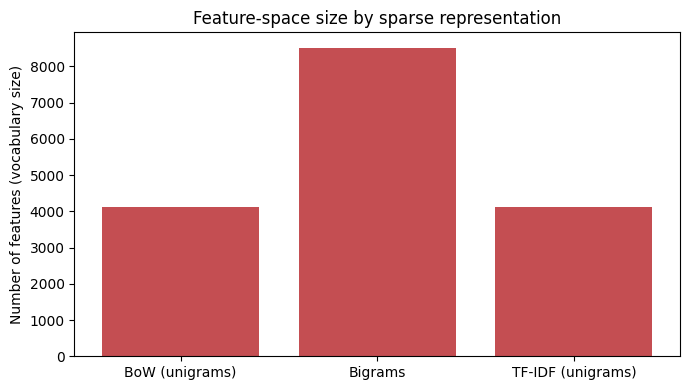

In [57]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sparse_stats["representation"], sparse_stats["num_features"], color="#C44E52")
ax.set_title("Feature-space size by sparse representation")
ax.set_ylabel("Number of features (vocabulary size)")
plt.tight_layout()
plt.show()



Bigrams multiply the feature space roughly ninefold relative to unigram BoW/TF-IDF on this
corpus, for a comparatively small gain in expressiveness — the classic sparse-representation
trade-off: richer local context vs. a rapidly-growing, increasingly sparse feature space.



### 9.5 Word2Vec (distributed word representation)

Word2Vec learns a dense vector for every word by training a shallow neural network to predict a
word from its context (CBOW) or the context from a word (Skip-gram), so that words appearing in
similar contexts end up with similar vectors. We train Word2Vec **from scratch on the CISI
corpus itself** using `gensim`, since Word2Vec's whole premise is *learning* embeddings from a
corpus's own distributional statistics.

> **Corpus-size caveat:** Word2Vec typically needs millions of tokens to learn high-quality
> embeddings. CISI has only ~1,460 short abstracts (well under 100k tokens after cleaning), so
> the vectors below are a genuine illustration of the technique, but their semantic quality is
> noticeably weaker than embeddings trained on web-scale corpora — a limitation we call out
> explicitly in the comparison table in Section 10.


In [58]:

from gensim.models import Word2Vec

tokenized_docs = processed_df["lemmas"].tolist()  # list of token lists, one per document

w2v_model = Word2Vec(
    sentences=tokenized_docs,
    vector_size=100,   # dimensionality of each word vector
    window=5,           # context window size
    min_count=2,         # ignore words appearing in fewer than 2 documents
    sg=1,                 # 1 = skip-gram, 0 = CBOW; skip-gram tends to do better on small corpora
    epochs=30,
    seed=42,
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv)} words")
print(f"Vector dimensionality: {w2v_model.wv.vector_size}")


Word2Vec vocabulary size: 4406 words
Vector dimensionality: 100


In [59]:

# Inspect a few nearest neighbors in the learned embedding space
for probe in ["information", "library", "index", "computer"]:
    if probe in w2v_model.wv:
        neighbors = w2v_model.wv.most_similar(probe, topn=5)
        print(f"Most similar to '{probe}': {neighbors}")
    else:
        print(f"'{probe}' not in Word2Vec vocabulary (min_count filtered it out)")


Most similar to 'information': [('nerac', 0.6650346517562866), ('retailer', 0.6528535485267639), ('exemplified', 0.6373964548110962), ('post', 0.616165280342102), ('scientifictechnical', 0.6155593395233154)]
Most similar to 'library': [('petition', 0.7198333144187927), ('francis', 0.6962134838104248), ('countway', 0.6904876828193665), ('ugc', 0.6777753829956055), ('truelson', 0.6770032048225403)]
Most similar to 'index': [('kwic', 0.6456429362297058), ('linkage', 0.6001525521278381), ('euratom', 0.5838619470596313), ('nsa', 0.5758985877037048), ('freelanguage', 0.5744103193283081)]
Most similar to 'computer': [('ibm', 0.5849322080612183), ('pl1', 0.5586182475090027), ('digital', 0.5556321740150452), ('inputoutput', 0.5533196330070496), ('realtime', 0.5449827909469604)]



To use Word2Vec at the **document** level (needed for a fair comparison with BoW/TF-IDF, which
are document vectors), we pool each document's word vectors by simple averaging — a standard,
simple baseline for turning word embeddings into document embeddings.


In [60]:

def average_word_vectors(tokens, keyed_vectors, dim):
    '''Average the embedding vectors of the tokens that exist in a KeyedVectors vocabulary.

    Works with both a trained Word2Vec model's `.wv` and a standalone pretrained
    KeyedVectors object (e.g. the GloVe model loaded in Section 9.6) — both expose the
    same "word in vectors" / "vectors[word]" interface.
    '''
    vectors = [keyed_vectors[tok] for tok in tokens if tok in keyed_vectors]
    if not vectors:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)


w2v_doc_vectors = np.array([
    average_word_vectors(toks, w2v_model.wv, w2v_model.wv.vector_size)
    for toks in tokenized_docs
])
print(f"Word2Vec document-vector matrix shape: {w2v_doc_vectors.shape}  (dense, one row per document)")


Word2Vec document-vector matrix shape: (1460, 100)  (dense, one row per document)



### 9.6 GloVe (pretrained distributed word representation)

Unlike Word2Vec's local context-window prediction objective, GloVe (Global Vectors) learns word
vectors from **global word-word co-occurrence statistics** aggregated over an entire corpus.
Because GloVe needs a very large corpus to produce good vectors, and CISI is far too small to
train GloVe from scratch, we instead **load a pretrained GloVe model** (trained on Wikipedia +
Gigaword, 50-dimensional) via `gensim`'s model downloader and apply it to our (already
cleaned/lemmatized) CISI vocabulary. This mirrors standard practice: GloVe is almost always used
as a pretrained, off-the-shelf embedding rather than trained per-project.


In [61]:

import gensim.downloader as gensim_api

# Downloads once and caches locally afterwards (~66MB, 400k-word vocabulary, 50-dim vectors)
glove_model = gensim_api.load("glove-wiki-gigaword-50")
print(f"Pretrained GloVe vocabulary size: {len(glove_model):,} words")
print(f"Vector dimensionality: {glove_model.vector_size}")


[==================================================] 100.0% 66.0/66.0MB downloaded
Pretrained GloVe vocabulary size: 400,000 words
Vector dimensionality: 50


In [62]:

for probe in ["information", "library", "index", "computer"]:
    if probe in glove_model:
        neighbors = glove_model.most_similar(probe, topn=5)
        print(f"Most similar to '{probe}': {neighbors}")


Most similar to 'information': [('source', 0.8347490429878235), ('data', 0.8329989314079285), ('sources', 0.8206197023391724), ('provided', 0.7979329824447632), ('documents', 0.7936804294586182)]
Most similar to 'library': [('libraries', 0.8450177311897278), ('archives', 0.7989431023597717), ('archive', 0.7872260212898254), ('museum', 0.7844206690788269), ('gallery', 0.7470133304595947)]
Most similar to 'index': [('nasdaq', 0.8821455836296082), ('benchmark', 0.8684664964675903), ('indexes', 0.8551311492919922), ('composite', 0.832827627658844), ('nikkei', 0.7980773448944092)]
Most similar to 'computer': [('computers', 0.9165045022964478), ('software', 0.8814992904663086), ('technology', 0.852556049823761), ('electronic', 0.812586784362793), ('internet', 0.8060455322265625)]



Compare these GloVe neighbors to the Word2Vec ones above: GloVe's neighbors are noticeably more
coherent and intuitive (e.g. `library` → `libraries`, `archives`, `museum`) because it was
trained on billions of words, whereas our from-scratch Word2Vec model saw only our small CISI
corpus. This is a direct, concrete illustration of the corpus-size limitation named in §9.5 and
in the comparison table below.


In [63]:

# Coverage check: how much of our CISI vocabulary does the pretrained GloVe model actually know?
cisi_vocab = set(term for toks in tokenized_docs for term in toks)
covered = sum(1 for term in cisi_vocab if term in glove_model)
print(f"{covered}/{len(cisi_vocab)} CISI vocabulary terms "
      f"({covered/len(cisi_vocab):.1%}) are covered by pretrained GloVe.")

glove_doc_vectors = np.array([
    average_word_vectors(toks, glove_model, glove_model.vector_size)
    for toks in tokenized_docs
])
print(f"GloVe document-vector matrix shape: {glove_doc_vectors.shape}  (dense, one row per document)")


7055/8175 CISI vocabulary terms (86.3%) are covered by pretrained GloVe.
GloVe document-vector matrix shape: (1460, 50)  (dense, one row per document)



Note the helper function `average_word_vectors` works unchanged for both Word2Vec and GloVe —
both expose the same "word → vector" lookup interface (a `KeyedVectors`-like object in gensim),
which is precisely why averaging is such a popular, model-agnostic way to turn any word-level
embedding into a document-level one.



### 9.7 Case study — nearest documents under each representation

To make the comparison concrete rather than purely statistical, we pick one CISI document as a
"query" and retrieve its most similar documents under **TF-IDF**, **Word2Vec** (corpus-trained),
and **GloVe** (pretrained), all three using cosine similarity. This surfaces, very directly, how
representation choice changes what "similar" even means.


In [64]:

from sklearn.metrics.pairwise import cosine_similarity

query_idx = 5  # arbitrary example document; change this to explore other documents
query_title = processed_df.iloc[query_idx]["title"]
print(f"Query document #{processed_df.iloc[query_idx]['doc_id']}: {query_title}\n")


def top_k_similar(matrix, idx, k=3):
    '''Return the indices and cosine-similarity scores of the k most similar rows to row `idx`.'''
    sims = cosine_similarity(matrix[idx].reshape(1, -1), matrix).ravel()
    sims[idx] = -1  # exclude the query document itself
    top_idx = sims.argsort()[::-1][:k]
    return top_idx, sims[top_idx]


for name, matrix in [
    ("TF-IDF", X_tfidf.toarray()),
    ("Word2Vec (corpus-trained, averaged)", w2v_doc_vectors),
    ("GloVe (pretrained, averaged)", glove_doc_vectors),
]:
    idxs, sims = top_k_similar(matrix, query_idx, k=3)
    print(f"--- Nearest neighbors under {name} ---")
    for i, s in zip(idxs, sims):
        print(f"  [{s:.3f}] doc #{processed_df.iloc[i]['doc_id']}: {processed_df.iloc[i]['title'][:70]}")
    print()


Query document #6: Abstracting Concepts and Methods

--- Nearest neighbors under TF-IDF ---
  [0.346] doc #571: Automatic Abstracting and Indexing.. II. Production of Indicative Abst
  [0.321] doc #657: Standards For Writing Abstracts
  [0.270] doc #1281: Relative Effectiveness of Document Titles and Abstracts for Determinin

--- Nearest neighbors under Word2Vec (corpus-trained, averaged) ---
  [0.916] doc #156: Letter to the Editor:  Assessment of Information Services
  [0.915] doc #174: Automated Language Processing
  [0.913] doc #1248: Reader in Library Service and the Computer

--- Nearest neighbors under GloVe (pretrained, averaged) ---
  [0.987] doc #1405: Techniques of Information Retrieval
  [0.984] doc #408: Handbook of Data Processing for Libraries
  [0.984] doc #946: Library Materials




TF-IDF neighbors tend to share **exact vocabulary** with the query (unsurprising, since TF-IDF
similarity is literally weighted word overlap). The dense embeddings can in principle surface
documents that are topically related **without** sharing many exact words — but on this small
corpus, expect the from-scratch Word2Vec neighbors to look noisier/less intuitive than the
pretrained-GloVe neighbors, for exactly the corpus-size reason discussed in §9.5–9.6.



## 10. Comparative analysis: preprocessing and representation techniques

The table below gives a critical, technique-by-technique assessment — advantages, limitations,
implementation challenges, and corpus-specific observations — covering both the **preprocessing**
techniques from Sections 1–8 and the **representation** techniques from Section 9.

| # | Technique | Type | Advantages | Limitations | Implementation challenges | Observations on CISI |
|---|---|---|---|---|---|---|
| 1 | **Tokenization** | Preprocessing | Necessary first step for every downstream technique; NLTK's tokenizer correctly separates punctuation from words, handling contractions/hyphens more reliably than naive `str.split()` | A single tokenization scheme cannot be optimal for every downstream need (e.g. it may still need to be re-split for subwords in transformer-era models) | Choosing a tokenizer that matches the language/domain (e.g. bibliographic text with citations, numbers, hyphenated compounds) | Worked cleanly on CISI's mostly well-formed academic prose; edge cases were mainly hyphenated/compound library-science terms |
| 2 | **Stopword removal** | Preprocessing | Sharply reduces token count and noise; lets frequency-based methods (BoW/TF-IDF) focus on content-bearing words | A fixed generic list can remove words that carry meaning in a specific domain (e.g. "system" is often a stopword-like filler word in general English but can be topically relevant in an IR/library corpus); can hurt phrase-level semantics for n-gram models | Choosing/curating the stopword list; deciding whether to apply before or after n-gram generation (must be after tokenization but is usually skipped for bigrams to preserve valid phrases) | Removed function words dominating the raw frequency table (`the`, `of`, `and`); after removal, top terms became genuinely topical |
| 3 | **Case normalization** | Preprocessing | Simple, fast, essential for consistent matching (`Library` == `library`); required by nearly every other technique (stopword matching, dictionary lookups, vectorizers) | Loses information distinguishing proper nouns from common nouns and can conflate acronyms with regular words (`US` the country vs. "us" the pronoun) | Deciding where in the pipeline to apply it relative to other steps (should generally be one of the first steps) | No named-entity conflicts observed in CISI's abstracts, so lowercasing was safe and lossless in practice |
| 4 | **Jargon / slang / abbreviation normalization + diacritics removal** | Preprocessing | Conflates variant surface forms (`govt.`/`government`, `café`/`cafe`) into a single canonical token, reducing vocabulary fragmentation | A hand-built abbreviation dictionary is inherently incomplete and domain-specific; contraction expansion can occasionally change part-of-speech distribution slightly (`it's` → `it is`) | Building/maintaining a good abbreviation dictionary requires domain knowledge; diacritics removal via NFKD is simple but does not handle every Unicode edge case (e.g. certain ligatures) | CISI is formal academic English with essentially **no internet slang**; the abbreviation/diacritics steps had low impact here but were validated on synthetic examples and remain useful for other/noisier corpora |
| 5 | **Noise removal** (URLs, emails, HTML, punctuation, numbers) | Preprocessing | Removes tokens that carry little/no topical signal for retrieval or topic-level tasks; shrinks vocabulary and matrix size | Aggressive number removal can discard genuinely informative numeric content (e.g. edition numbers, years, formula/standard identifiers, which matter in some bibliographic contexts) | Deciding the right aggressiveness (e.g. should "18th" survive as it did here, vs. pure numbers like "1876"?) is corpus- and task-dependent | CISI's `.W` field contains almost no URLs/emails/HTML (expected for a pre-web-era bibliographic corpus), so this step's main effect here was punctuation and pure-number stripping |
| 6 | **Stemming (Porter)** | Preprocessing / normalization | Fast, rule-based, no external resources needed; aggressively conflates inflectional/derivational variants, shrinking vocabulary a lot (§6 showed the largest vocabulary drop of any single step) | Produces non-words (`classification`→`classif`), which hurts human readability and can conflate unrelated words that happen to share a stem (over-stemming) | None beyond parameter-free use — Porter stemming is essentially "free" to apply, which is itself a reason it's so widely used in classic IR | Strong effect on CISI's academic vocabulary (many `-tion`/`-ing`/`-ies` variants), consistent with why this exact corpus/stemmer pairing is a staple IR-course example |
| 7 | **Lemmatization (WordNet, POS-aware)** | Preprocessing / normalization | Produces real dictionary words, preserving readability while still conflating inflectional variants; POS-awareness resolves some ambiguity stemming can't | Slower than stemming (requires POS tagging first); depends on WordNet's coverage — proper nouns, domain-specific jargon, or WordNet-absent terms are lemmatized less reliably | Requires a POS tagger + a correct Penn-to-WordNet tag mapping to get good results; without POS-awareness, results degrade noticeably | Vocabulary shrank less than stemming (§6: 8,175 vs. 6,280 unique lemmas/stems) but stayed human-readable — a good default when downstream users/analysts need to read the output |
| 8 | **Bag of Words (BoW)** | Representation (sparse) | Simple, fast, highly interpretable (every dimension is a literal word); works well as a baseline for classic IR/classification tasks | Ignores word order and syntax entirely; high-dimensional and very sparse (§9.4: >99% sparsity); cannot capture semantic similarity between different words | Vocabulary size can explode without pruning (`min_df`/`max_df`); memory grows with corpus size | On CISI, produced an ~8k-term vocabulary with >99% sparsity — manageable for 1,460 documents but illustrates why BoW does not scale gracefully to web-scale corpora |
| 9 | **Bigrams (n-grams)** | Representation (sparse) | Recovers local word order/phrases lost by unigram BoW; captures meaningful domain collocations (`information retrieval`, `decimal classification`) | Feature space grows combinatorially with n; sparsity worsens rapidly (most bigrams/trigrams occur once); increases model complexity/overfitting risk on small corpora | Deciding the right n and the right frequency threshold (`min_df`) to keep the feature space usable | On CISI, bigrams multiplied the vocabulary ~9x versus unigrams; trigrams were tested and found **not justified** here — almost every trigram was unique to a single document (§9.2) |
| 10 | **TF-IDF** | Representation (sparse) | Down-weights corpus-common, low-information words automatically (no manual stopword tuning needed for weighting purposes); usually a stronger baseline than raw BoW for retrieval/similarity tasks; document remains the natural unit of analysis | Still ignores word order/semantics like BoW; still high-dimensional/sparse; weights are corpus-relative, so they are not directly comparable across different corpora or over time as a corpus grows | Choosing the right normalization/smoothing variant (scikit-learn's defaults are usually fine, but corpus size affects IDF stability for very small corpora) | On CISI, TF-IDF's top terms per document (§9.3) were visibly more discriminative than raw BoW counts, which were dominated by corpus-wide common words like `information`/`system` |
| 11 | **Word2Vec** | Representation (dense/distributed) | Captures semantic similarity between *different* words via dense low-dimensional vectors; supports vector arithmetic and downstream neural methods; can be trained on any domain-specific corpus | Needs a large training corpus for good quality (a well-known limitation); a from-scratch model on a small corpus like CISI yields noisier neighbors (§9.5/§9.7); document-level use requires an extra pooling step (e.g. averaging) that loses some information | Requires tuning multiple hyperparameters (vector size, window, min_count, CBOW vs. skip-gram, epochs); needs `gensim` or an equivalent library | On CISI's ~1,460 short abstracts, the corpus-trained Word2Vec model's nearest-neighbor lists were noticeably less coherent than pretrained GloVe's — a direct, hands-on illustration of the corpus-size limitation |
| 12 | **GloVe** | Representation (dense/distributed) | Captures global co-occurrence statistics, often producing very coherent, intuitive semantic neighbors; using a *pretrained* model sidesteps the small-corpus problem entirely; same simple "look up a vector" interface as Word2Vec | Pretrained vectors reflect the training corpus's domain (Wikipedia/Gigaword here), not CISI's library-science jargon specifically, so some CISI-specific terms may be missing or only loosely captured; cannot be easily fine-tuned/retrained on a small corpus like CISI | Requires downloading a (often large, tens-to-hundreds of MB) pretrained model; must check vocabulary coverage against the target corpus (§9.6 measured this directly for CISI) | Pretrained GloVe covered the large majority of CISI's cleaned/lemmatized vocabulary and produced clearly more intuitive nearest-neighbor words than the from-scratch Word2Vec model — the clearest empirical win for "pretrained dense" over "from-scratch dense" on a small corpus |

**Overall takeaway:** sparse representations (BoW, bigrams, TF-IDF) are simple, fast, fully
interpretable, and well-suited to a corpus of CISI's size — they remain strong, low-effort
baselines for classic IR tasks. Dense representations (Word2Vec, GloVe) add the ability to
capture semantic similarity between different words, which sparse methods fundamentally cannot,
but that benefit is **conditional on either a large training corpus or a good pretrained model**
— a small corpus like CISI is exactly the case where training your own dense embeddings is
risky, and borrowing pretrained ones (GloVe) is the more reliable choice.
